# Solar Calibration Tutorial 

## 1) Environment and Setup 

Before running the notebook:

- Use Python 3.12.
- Install project dependencies (including notebook extras): `uv sync --group notebook`. This should be executed in the terminal window.
- Ensure NetCDF support is available (`xarray` + `netCDF4`) because ERA5 loading and ingestion depends on it.

> If `uv` is not available in your environment, install dependencies with your standard Python package workflow.

In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from rencal.calibration.solar.solar_calibrator import SolarCalibrator

## 2) Required Input Folder Structure and Files 

`SolarCalibrator` expects a base `data_path` with these subfolders: 

- `plant/solar_plant_data`
- `generation/generation_data.parquet`
- `era5/*.nc`




In [34]:
DATA_PATH = Path("../../data/")
OUTPUT_PATH = DATA_PATH / "outputs" / "tutorials" / "solar_calibration"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH.resolve())
print("Output path:", OUTPUT_PATH.resolve())

Data path: C:\Users\WestcottE\Solar calibration\rencal\data
Output path: C:\Users\WestcottE\Solar calibration\rencal\data\outputs\tutorials\solar_calibration


## 3) Downloading the Calibration Inputs

The calibration workflow needs three input datasets:

1. **Plant data**: Plant metadata and CfD/BMU mapping. Ingested through the `CfDDataDownloader` via an API from the Low Carbon Contracts Company (LCCC)
2. **Generation data**: Historical generation for those plants. Ingested through the `GenerationDataDownloader` via an API from Elexon BMRS.
3. **ERA5 weather data**: Hourly reanalysis weather data for the nearest available location to the generator in NetCDF format. Ingested through the `ERA5DataDownloader` from the Copernicus Climate Data Store via `cdsapi`

This repository provides a `DownloadManager` that downloads and saves these inputs into the expected folder structure under `data/`:

- `data/plant/`
- `data/generation/`
- `data/era5/`

> Note: ERA5 downloads require a valid `CDS_API_KEY`. This can be saved in .env-example.

In [35]:
from rencal.core.data_downloader import DownloadManager

In [36]:

# dm = DownloadManager()

# # Download everything needed for calibration
# dm.download_all()

## Optional: Download data step-by-step 

In [37]:

dm = DownloadManager()

# # 1. Download plant metadata / CfD mapping
# dm.download_cfd()

# 2. Download generation data for those plants in CfD metadata
dm.download_generation_data()

# # 3. Download ERA5 weather data
# dm.download_era5()

[INFO] - Loading CfD plant data with BMU mapping... - [data_downloader] - 2026-09-03 15:06:02
[INFO] - Found 109 unique BMU IDs. - [data_downloader] - 2026-09-03 15:06:02


## Manually downloading ERA5 data

Login to CDS to get your API key. 

Set up according to https://cds.climate.copernicus.eu/how-to-api

From `contants.py`: 
`ERA5_DATASET = "reanalysis-era5-single-levels"`
`AREA_BOUNDING_BOX_COORDINATES = [61, -12, 49, 5]  # [North, West, South, East] - UK bounding box`
`DEFAULT_SOLAR_VARIABLES = ["surface_solar_radiation_downwards", "2m_temperature"]`


## Merge Files into one era5 file 


In [38]:
# import xarray as xr
# from pathlib import Path

# era5_dir = Path(r"c:\Users\WestcottE\Solar calibration\rencal\data\era5")
# files = sorted(era5_dir.glob("*.nc"))
# print(files)

# ds = xr.merge([xr.open_dataset(f) for f in files])

# # print(ds.sizes["valid_time"])
# # print(ds.indexes["valid_time"].duplicated().sum())
# # print(list(ds.data_vars))             


# if "valid_time" in ds.dims:
#     ds = ds.rename({"valid_time": "time"})
    
# out_dir = era5_dir.parent / "era5"
# out_dir.mkdir(exist_ok=True)
# ds.to_netcdf(out_dir / "era5_2025.nc")
# ds.close()

## Pre-Check: verify that all data has been downloaded

In [ ]:
required_paths = [
    DATA_PATH / "plant",
    DATA_PATH / "era5",
    DATA_PATH / "plant" / "plant_data.csv",
    DATA_PATH / "generation" / "generation_data.parquet",
]

required_path_generation = [DATA_PATH / "generation"]

plant_data = pd.read_csv(DATA_PATH / "plant" / "plant_data.csv")
generation_data = pd.read_parquet(DATA_PATH / "generation" / "generation_data.parquet")

print(generation_data.head())

['AAA-ACH-183' 'AAA-BAD-185' 'AAA-BAN-189' 'AAA-PNE-187' 'AR2-HRN-106'
 'AR2-HRN-206' 'AR2-HRN-306' 'AR4-BCW-610' 'AR4-BSP-700' 'AR4-CLH-710'
 'AR4-CWS-610' 'AR4-KWE-610' 'AR4-LSF-700' 'AR5-BWI-610' 'AR6-BEN-610'
 'AR6-BWA-610' 'AR6-CRI-610' 'AR6-KHW-600' 'INV-BUR-001' 'INV-DUD-003'
 'INV-HOR-001' 'INV-HOR-002' 'INV-HOR-003' 'INV-WAL-001' 'INV-WAL-002']


: 

In [40]:
required_paths = [
    DATA_PATH / "plant",
    DATA_PATH / "era5",
    DATA_PATH / "plant" / "plant_data.csv",
    DATA_PATH / "generation" / "generation_data.parquet",
]

required_path_generation = [DATA_PATH / "generation"]

plant_data = pd.read_csv(DATA_PATH / "plant" / "plant_data.csv")
generation_data = pd.read_parquet(DATA_PATH / "generation" / "generation_data.parquet")

print(generation_data['cfd_id'].dropna().unique())
for p in required_paths:
    print(f"{p}: {'Exists' if p.exists() else 'MISSING'}")

start = generation_data["time"].min()
end = generation_data["time"].max()

for path in required_path_generation:
    status = "Exists" if path.exists() else "MISSING"
    print(f"{path}: {status} | range: {start} → {end}")

era5_files = sorted((DATA_PATH / "era5").glob("*.nc"))
print(f"ERA5 files found: {len(era5_files)}")
for path in era5_files[:10]:
    print(f"  - {path.name}")
if len(era5_files) > 10:
    print(f"  ... and {len(era5_files) - 10} more")
    


['AAA-ACH-183' 'AAA-BAD-185' 'AAA-BAN-189' 'AAA-PNE-187' 'AR2-HRN-106'
 'AR2-HRN-206' 'AR2-HRN-306' 'AR4-BCW-610' 'AR4-BSP-700' 'AR4-CLH-710'
 'AR4-CWS-610' 'AR4-KWE-610' 'AR4-LSF-700' 'AR5-BWI-610' 'AR6-BEN-610'
 'AR6-BWA-610' 'AR6-CRI-610' 'AR6-KHW-600' 'INV-BUR-001' 'INV-DUD-003'
 'INV-HOR-001' 'INV-HOR-002' 'INV-HOR-003' 'INV-WAL-001' 'INV-WAL-002']
..\..\data\plant: Exists
..\..\data\era5: Exists
..\..\data\plant\plant_data.csv: Exists
..\..\data\generation\generation_data.parquet: Exists
..\..\data\generation: Exists | range: 2023-01-01 00:00:00+00:00 → 2026-08-26 22:00:00+00:00
ERA5 files found: 1
  - era5_2025.nc


In [41]:
# display(generation_data)

## Optional pre check: verify ERA5 NetCDF can be opened 

If this fails, calibration will fail during ERA5 loading. 

In [42]:
if era5_files:
    test_file = era5_files[0]
    print("Testing ERA5 file:", test_file)
    try:
        ds = xr.open_dataset(test_file, engine="netcdf4")
        print("Opened successfully. Variables:", list(ds.data_vars)[:10])
        ds.close()
    except Exception as exc:
        print("Failed to open ERA5 file with netcdf4:", exc)
else:
    print("No ERA5 files found. Add .nc files under data/era5/.")
    


Testing ERA5 file: ..\..\data\era5\era5_2025.nc
Opened successfully. Variables: ['ssrd', 't2m', 'u100', 'v100']


In [43]:
print(dict(ds.sizes))
print(list(ds.coords))
print(list(ds.data_vars))

{'time': 4344, 'latitude': 49, 'longitude': 69}
['number', 'time', 'latitude', 'longitude', 'expver']
['ssrd', 't2m', 'u100', 'v100']


## 4) Import and configure `SolarCalibrator` 

Key Arguments:

- `data_path`: base folder containing `plant/ , generation/, era5/`
- `output_path` : calibration outputs written 
- `visual_output`: visual_output (bool): If True, each calibrated plant's power curve is plotted to the output folder.
- `stream_npy_outputs`: saves solar streams in NPY format alongside PARQUET
- 


In [44]:
ds.close()

In [45]:
sc = SolarCalibrator(
    data_path=str(DATA_PATH),
    output_path=OUTPUT_PATH,
    visual_output=True,
    stream_npy_output=True,
)

[INFO] - Plant data loaded: 552 plants, 49241.3 MW total capacity - [data_loader] - 2026-09-03 15:06:03


[INFO] - Generation data loaded: 585509 records, 25 plants - [data_loader] - 2026-09-03 15:06:03
[INFO] - ERA5 data loaded: 1 files, 4344 time periods - [data_loader] - 2026-09-03 15:06:03


## 5) Run Calibration

This executes the full worrkflow and writes outputs to `output_path`.

Calibration is performed in a step wise process: 

- `NOCT and gamma` parameters 
- `Calibration Summary`


** add in methodology here 

In [46]:
# print(sc.summary)

In [47]:
# 1
sc.plant_irradiance = sc.extract_resource_timeseries_for_plants()
sc.plant_irradiance.head()

[INFO] - Resource data pre-merged by CDS; dropping expver label. - [solar_calibrator] - 2026-09-03 15:06:03
[INFO] - Extracting solar irradiance for plants... - [solar_calibrator] - 2026-09-03 15:06:03


,time,plant_id,irradiance,temperature
0,2025-01-01 00:00:00+00:00,AR4-CLH-710,0.0,283.775391
1,2025-01-01 00:00:00+00:00,AR4-EST-700,0.0,284.050781
2,2025-01-01 00:00:00+00:00,AR4-STV-700,0.0,283.525391
3,2025-01-01 00:00:00+00:00,AR7-LTL-700,0.0,283.482422
4,2025-01-01 00:00:00+00:00,AR4-BSP-700,0.0,284.201172


In [48]:
# 2
sc.output_path.mkdir(parents=True, exist_ok=True)
sc.output_resource_per_plant()

[INFO] - Written plant‑wise solar resource dataset to ..\..\data\outputs\tutorials\solar_calibration\Solar Resource.csv - [solar_calibrator] - 2026-09-03 15:06:21


In [49]:
# 3 — note: this deletes sc.resource, so re-running step 1 needs a fresh sc
del sc.resource
sc.generation.data = sc._clip_generation_to_plant_capacity()
sc.generation.data.head()

,plant_id,time,quantity
0,AAA-ACH-183,2023-01-01 00:00:00+00:00,0.00
1,AAA-ACH-183,2023-01-01 01:00:00+00:00,0.00
2,AAA-ACH-183,2023-01-01 02:00:00+00:00,0.00
3,AAA-ACH-183,2023-01-01 03:00:00+00:00,0.00
4,AAA-ACH-183,2023-01-01 04:00:00+00:00,0.13


In [50]:
# 4
sc.historical_load_factors = sc.calculate_historical_load_factors()
sc.historical_load_factors.head()

[INFO] - Calculating historical load factors... - [solar_calibrator] - 2026-09-03 15:06:22


,time,plant_id,irradiance,temperature,quantity,latitude,longitude,technology,capacity,bmu_id,load_factor
0,2025-01-01 00:00:00+00:00,AR4-CLH-710,0.0,283.779999,0.0,51.34,0.93,Solar PV,109.79,T_CLVHS-1,0.0
1,2025-01-01 00:00:00+00:00,AR4-BSP-700,0.0,284.200012,0.0,52.16,-2.00,Solar PV,30.00,C__ESTAT019,0.0
2,2025-01-01 00:00:00+00:00,AR4-LSF-700,0.0,284.260010,0.0,51.05,-4.12,Solar PV,49.90,C__LSTAT020,0.0
3,2025-01-01 01:00:00+00:00,AR4-CLH-710,0.0,283.809998,0.0,51.34,0.93,Solar PV,109.79,T_CLVHS-1,0.0
4,2025-01-01 01:00:00+00:00,AR4-BSP-700,0.0,284.269989,0.0,52.16,-2.00,Solar PV,30.00,C__ESTAT019,0.0


In [51]:
# 5
sc.historical_load_factor_distributions = sc.fit_historical_load_factor_distribution()
sc.output_historical_load_factor_distribution_parameters()

[INFO] - Fitting irradiance histograms for historical load factors... - [solar_calibrator] - 2026-09-03 15:06:22
[INFO] - Written solar irradiance distribution parameters to ..\..\data\outputs\tutorials\solar_calibration\Solar Distribution Params.csv - [solar_calibrator] - 2026-09-03 15:06:22


In [52]:
# 6
sc.summary = sc.estimate_load_factors_for_resource()
sc.summary

[INFO] - Estimating long term solar load factors for plants... - [solar_calibrator] - 2026-09-03 15:06:22
[WARNING] - Skipping AAA-ACH-183 (no valid irradiance data). - [solar_calibrator] - 2026-09-03 15:06:22
[WARNING] - Skipping AAA-BAD-185 (no valid irradiance data). - [solar_calibrator] - 2026-09-03 15:06:22
[WARNING] - Skipping AAA-BAN-189 (no valid irradiance data). - [solar_calibrator] - 2026-09-03 15:06:22
[WARNING] - Skipping AAA-PNE-187 (no valid irradiance data). - [solar_calibrator] - 2026-09-03 15:06:22
[WARNING] - Skipping AR2-HRN-106 (no valid irradiance data). - [solar_calibrator] - 2026-09-03 15:06:22
[WARNING] - Skipping AR2-HRN-206 (no valid irradiance data). - [solar_calibrator] - 2026-09-03 15:06:22
[WARNING] - Skipping AR2-HRN-306 (no valid irradiance data). - [solar_calibrator] - 2026-09-03 15:06:22
[WARNING] - Skipping AR4-BCW-610 (no valid irradiance data). - [solar_calibrator] - 2026-09-03 15:06:22
[INFO] - Written PV curve fit plot to ..\..\data\outputs\tutor

,plant_id,gamma,NOCT,estimated_load_factor
0,AR4-BSP-700,0.000540,1.000000e+02,0.1228
1,AR4-CLH-710,0.002202,7.006868e-16,0.0746
2,AR4-LSF-700,0.001279,1.000000e+02,0.0904


In [53]:
# 7
sc._create_generic_solar_curve()
sc._rename_output_summary_columns()
sc.output_estimated_load_factors_tabular()

[INFO] - Written solar load factor summary to ..\..\data\outputs\tutorials\solar_calibration\Solar Calibration Summary.csv - [solar_calibrator] - 2026-09-03 15:06:23


In [54]:
# 8
sc.solar_streams = sc.generate_resource_streams()
sc.output_resource_streams()

[INFO] - Generating solar streams for plants... - [solar_calibrator] - 2026-09-03 15:06:23
[INFO] - Written solar streams to ..\..\data\outputs\tutorials\solar_calibration\Solar Streams.parquet - [solar_calibrator] - 2026-09-03 15:06:24
[INFO] - Written solar streams to ..\..\data\outputs\tutorials\solar_calibration\Solar Streams.npy - [solar_calibrator] - 2026-09-03 15:06:24


In [55]:
# sc.calibrate()

## 6) Inspect Outputs 

After Calibration is completed, this notebook should produce 

- Solar Distribution Paramters (csv)
- Solar irradiance and temperature series for each plant to a csv file 
- Solar load factor stream (parquet or npy)
- Solar calibration summary (csv)





In [56]:
# list of the generated outputs
sorted([p.name for p in OUTPUT_PATH.glob("*")])

['PV_Curve_Fit_AR4-BSP-700.png',
 'PV_Curve_Fit_AR4-CLH-710.png',
 'PV_Curve_Fit_AR4-LSF-700.png',
 'Solar Calibration Summary.csv',
 'Solar Distribution Params.csv',
 'Solar Resource.csv',
 'Solar Streams.npy',
 'Solar Streams.parquet']

### Output 1 - Distribution Paramaters 


In [57]:
distribution = pd.read_csv(OUTPUT_PATH / "Solar Distribution Params.csv")

display(distribution)

,plant_id,irradiance_mean,irradiance_stdev,histogram,bin_edges
0,AR4-CLH-710,166.33888,235.39926,[2.14376151e-02 1.47713321e-03 1.04550338e-03 ...,[ 0. 24. 48. 72. 96. 120. 144. 16...
1,AR4-BSP-700,147.49467,215.95583,[2.16965930e-02 1.69774401e-03 1.29488950e-03 ...,[ 0. 24. 48. 72. 96. 120. 144. 16...
2,AR4-LSF-700,149.43756,218.24020,[2.17349601e-02 1.54427563e-03 1.30448128e-03 ...,[ 0. 24. 48. 72. 96. 120. 144. 16...


### - Calibration Summary 

Calibration Summary CSV containg gamma, NOCT and Estimated Load Factor 

In [58]:
summary = pd.read_csv(OUTPUT_PATH / "Solar Calibration Summary.csv")

display(summary)

,PLANT ID,Gamma,NOCT,Estimated Load Factor
0,AR4-BSP-700,0.000540,1.000000e+02,0.1228
1,AR4-CLH-710,0.002202,7.006868e-16,0.0746
2,AR4-LSF-700,0.001279,1.000000e+02,0.0904
3,Generic Solar,0.001279,1.000000e+02,0.0000


### Solar Resource 


In [59]:
from rencal.utils.constants import INTERNAL_PLANT_ID

print(len(sc.calibration_plant_ids))
print(sc.plants.data[INTERNAL_PLANT_ID].nunique())
print(len(set(sc.calibration_plant_ids) & set(sc.plants.data[INTERNAL_PLANT_ID])))

25
368
3


In [60]:

solar_resource = pd.read_csv(OUTPUT_PATH / "Solar Resource.csv")

display(solar_resource)
                                        

,time,plant_id,irradiance,temperature
0,2025-01-01 00:00:00+00:00,AR4-CLH-710,0.0,283.77540
1,2025-01-01 00:00:00+00:00,AR4-EST-700,0.0,284.05078
2,2025-01-01 00:00:00+00:00,AR4-STV-700,0.0,283.52540
3,2025-01-01 00:00:00+00:00,AR7-LTL-700,0.0,283.48242
4,2025-01-01 00:00:00+00:00,AR4-BSP-700,0.0,284.20117
...,...,...,...,...
1598587,2025-06-30 23:00:00+00:00,AR7-GWL-700,0.0,290.80810
1598588,2025-06-30 23:00:00+00:00,AR5-LAD-700,0.0,294.37256
1598589,2025-06-30 23:00:00+00:00,AR6-RAS-700,0.0,294.39404
1598590,2025-06-30 23:00:00+00:00,AR5-BRH-700,0.0,293.87450


### Solar Streams

In [61]:
solar_streams = pd.read_parquet(OUTPUT_PATH / "Solar Streams.parquet")

display(solar_streams)

,Times,AAA-CAM-197,AAA-LIG-176,AAA-REG-175,AR4-ADS-700,AR4-ASF-700,AR4-BFS-700,AR4-BHL-700,AR4-BHS-700,AR4-BRC-700,...,AR7-WEA-700,AR7-WEB-710,AR7-WEL-700,AR7-WGS-700,AR7-WIH-700,AR7-WOO-700,AR7-WRS-700,AR7-WWS-700,AR7-WYE-700,AR7-WYM-710
0,2025-01-01 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2025-01-01 01:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2025-01-01 02:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2025-01-01 03:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2025-01-01 04:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4339,2025-06-30 19:00:00+00:00,0.107375,0.107004,0.115697,0.116454,0.122964,0.108330,0.114991,0.107055,0.117452,...,0.080757,0.114782,0.081664,0.119976,0.110379,0.105181,0.116856,0.110457,0.115850,0.111993
4340,2025-06-30 20:00:00+00:00,0.035039,0.040563,0.038404,0.040682,0.045487,0.035732,0.038159,0.042489,0.039701,...,0.028545,0.042583,0.031550,0.041090,0.036956,0.033133,0.038989,0.045500,0.044298,0.038099
4341,2025-06-30 21:00:00+00:00,0.001355,0.003784,0.001140,0.001790,0.003022,0.001171,0.001160,0.003742,0.001953,...,0.006313,0.002968,0.006578,0.004380,0.001123,0.000757,0.001237,0.003218,0.002863,0.001283
4342,2025-06-30 22:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Solar Streams vs Actual Generation

Solar power curve plot outputs showing the relationship between estimated and actual load factors for a given plant_id. Estimated load factors are taken from solar_streams, while actual load factors are calculated from metered generation data as quantity / capacity. The two series are merged on cfd_id and time, filtered to a single plant, and plotted as a time series comparison.

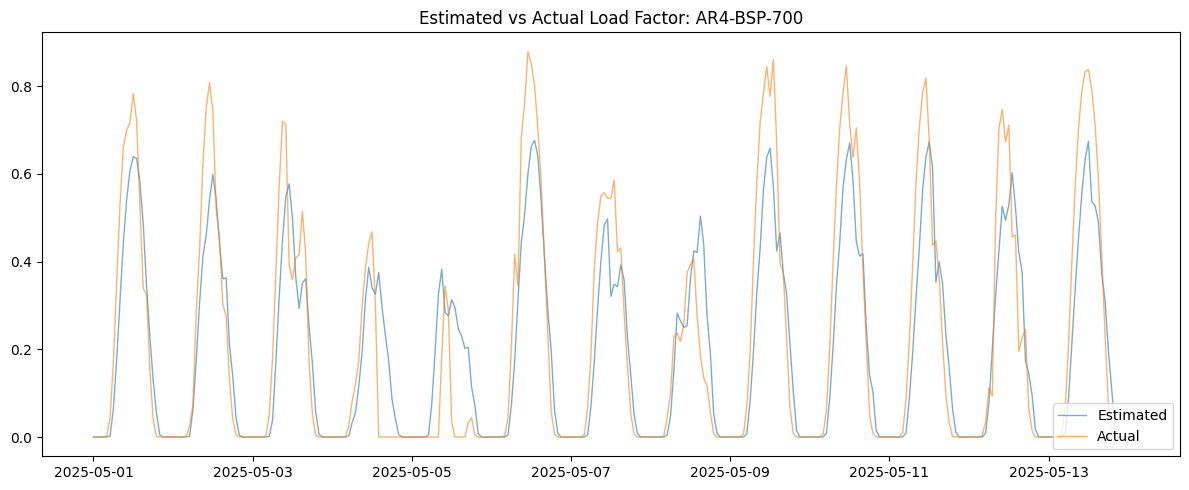

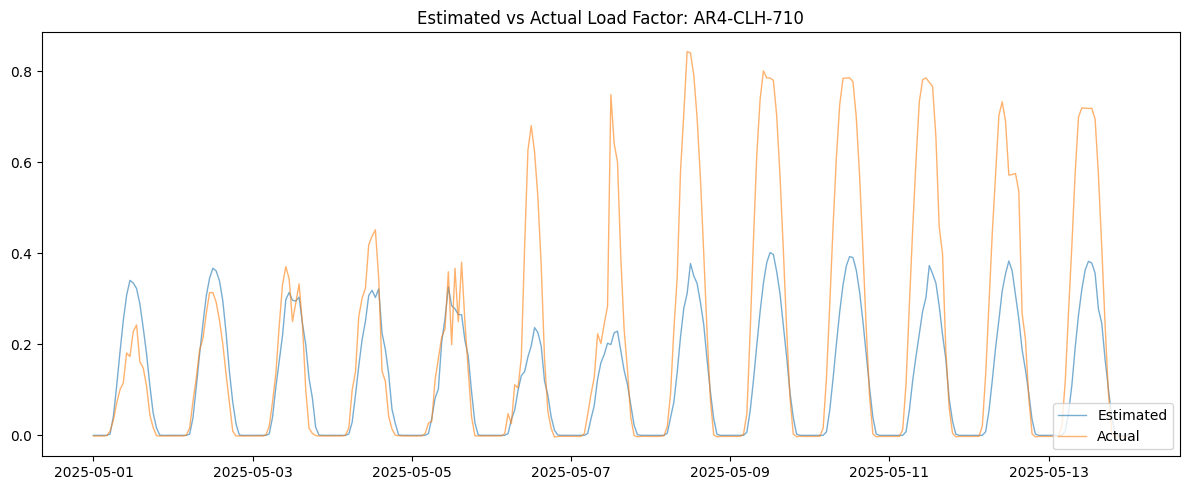

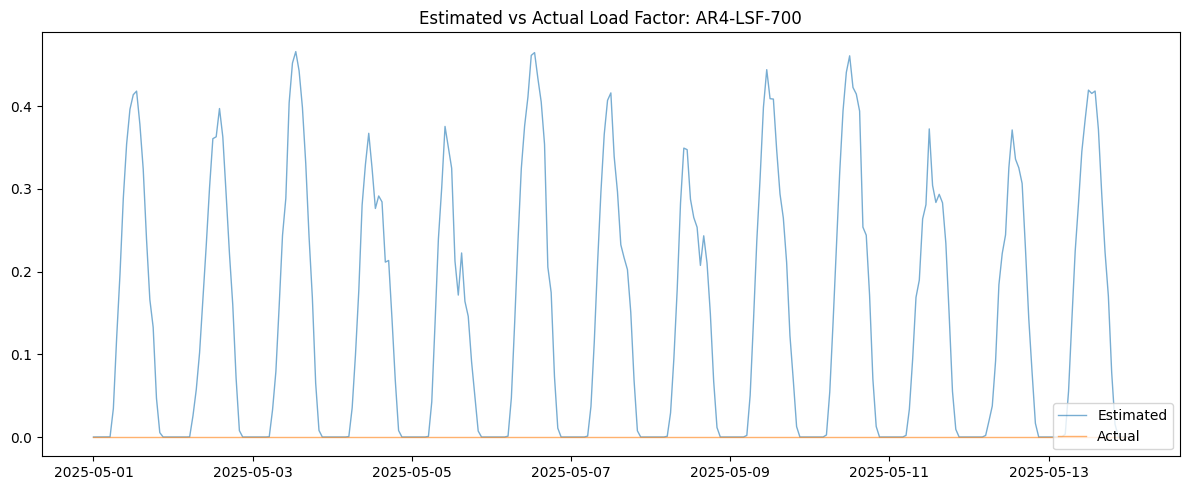

In [62]:
solar_long = solar_streams.rename(columns={"Times": "time"}).melt(
    id_vars="time",
    var_name="cfd_id",
    value_name="estimated_load_factor",
)

solar_long["time"] = pd.to_datetime(solar_long["time"], utc=True)
generation_data["time"] = pd.to_datetime(generation_data["time"], utc=True)

generation_data_capacity = generation_data.merge(
    plant_data[["cfd_id", "capacity"]],
    on="cfd_id",
    how="inner",
)

generation_data_capacity["actual_load_factor"] = (
    generation_data_capacity["quantity"] / generation_data_capacity["capacity"]
)

df = solar_long.merge(
    generation_data_capacity[["cfd_id", "time", "actual_load_factor"]],
    on=["cfd_id", "time"],
    how="inner",
)

plant_ids = ["AR4-BSP-700", "AR4-CLH-710", "AR4-LSF-700"]

for plant_id in plant_ids:
    plot_df = df[df["cfd_id"] == plant_id].sort_values("time")
    plot_df = plot_df[plot_df["time"].between("2025-05-01", "2025-05-14")]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df["time"], plot_df["estimated_load_factor"],
            label="Estimated", alpha=0.6, linewidth=1)
    ax.plot(plot_df["time"], plot_df["actual_load_factor"],
            label="Actual", alpha=0.6, linewidth=1)
    ax.set_title(f"Estimated vs Actual Load Factor: {plant_id}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

### Output 6 - Power Curves

In [63]:
lf = sc.historical_load_factors
high = lf[lf["irradiance"] > 400]
print(len(high), (high["load_factor"] == 0).mean())

2174 0.32750689972401104


Found 3 PNG files.



### PV_Curve_Fit_AR4-BSP-700.png

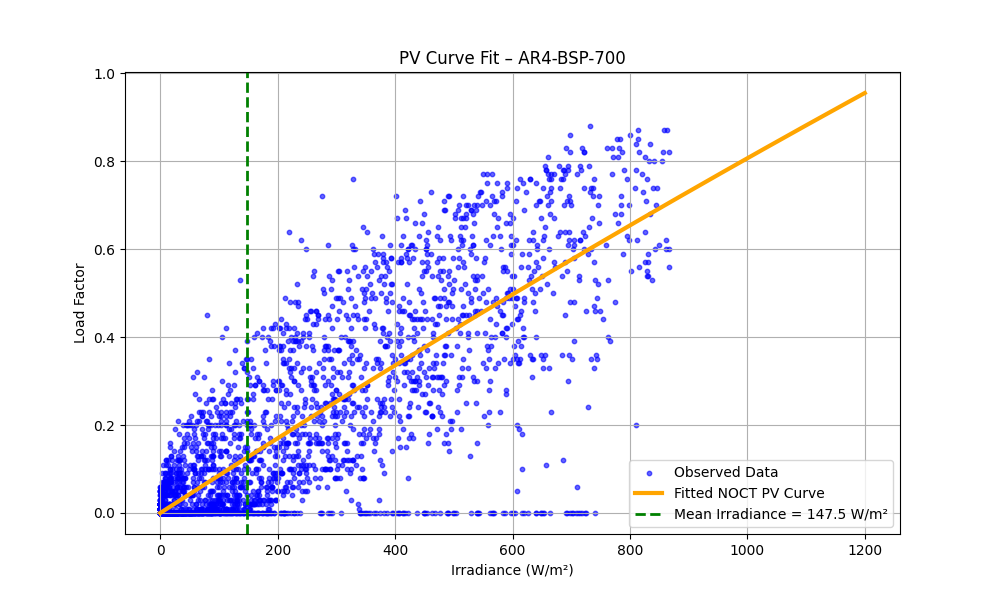

### PV_Curve_Fit_AR4-CLH-710.png

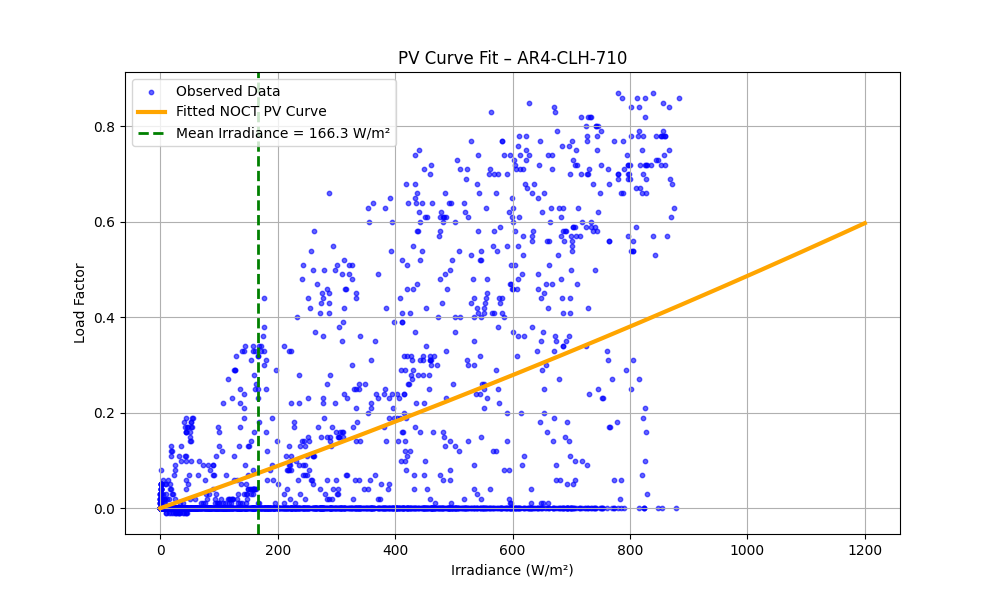

### PV_Curve_Fit_AR4-LSF-700.png

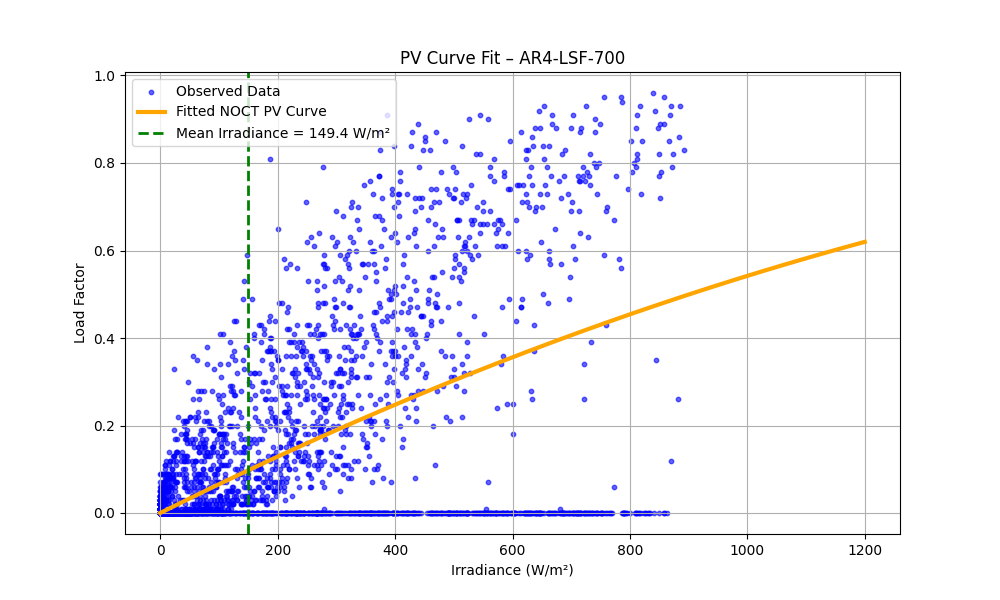

In [64]:

from IPython.display import Image, Markdown, display

png_files = sorted(Path(OUTPUT_PATH).glob("PV_Curve_Fit_*.png"))

if not png_files:
    print("No PNG files found.")
else:
    print(f"Found {len(png_files)} PNG files.\n")
    for png in png_files:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png)))